<a href="https://colab.research.google.com/github/Kaidense2026/Pop_culture-/blob/main/Pop_Culture_research_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, model_selection, metrics

In [90]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [45]:
import pandas as pd



url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Box%20Office%20Movies%20Data/movies_box_office.csv"



movies = pd.read_csv(url)



movies.head()






,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,8.4,927000.0,Stanley Kubrick,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,5.8,65000.0,Randal Kleiser,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,8.7,1200000.0,Irvin Kershner,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,7.7,221000.0,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,7.3,108000.0,Harold Ramis,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [46]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   score     7665 non-null   float64
 5   votes     7665 non-null   float64
 6   director  7668 non-null   object 
 7   star      7667 non-null   object 
 8   country   7665 non-null   object 
 9   budget    5497 non-null   float64
 10  gross     7479 non-null   float64
 11  company   7651 non-null   object 
 12  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 778.9+ KB


In [47]:
print(movies.shape)

(7668, 13)


In [48]:
movies.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


Checking for duplicates and nulls:

In [49]:
movies.duplicated().sum()


np.int64(0)

In [50]:
movies[movies.duplicated()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime


In [51]:
movies.isna()

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,False,True,False,False,False,False,False,False,False,False,True,True,False
7664,False,True,False,False,False,False,False,False,False,True,True,False,False
7665,False,True,False,False,False,False,False,False,False,False,True,False,True
7666,False,True,False,False,True,True,False,False,False,False,True,True,False


In [52]:
movies.isna().sum()

,0
name,0
rating,77
genre,0
year,0
score,3
votes,3
director,0
star,1
country,3
budget,2171


In [53]:
movies[movies['budget'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
16,Fame,R,Drama,1980,6.6,21000.0,Alan Parker,Eddie Barth,United States,NaN,21202829.0,Metro-Goldwyn-Mayer (MGM),134.0
19,Stir Crazy,R,Comedy,1980,6.8,26000.0,Sidney Poitier,Gene Wilder,United States,NaN,101300000.0,Columbia Pictures,111.0
24,Urban Cowboy,PG,Drama,1980,6.4,14000.0,James Bridges,John Travolta,United States,NaN,46918287.0,Paramount Pictures,132.0
25,Altered States,R,Horror,1980,6.9,33000.0,Ken Russell,William Hurt,United States,NaN,19853892.0,Warner Bros.,102.0
26,Little Darlings,R,Comedy,1980,6.5,5100.0,Ron Maxwell,Tatum O'Neal,United States,NaN,34326249.0,Stephen Friedman/Kings Road Productions,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7657,Leap,NaN,Drama,2020,6.7,903.0,Peter Ho-Sun Chan,Gong Li,China,NaN,25818882.0,NaN,135.0
7659,I Am Fear,Not Rated,Horror,2020,3.4,447.0,Kevin Shulman,Kristina Klebe,United States,NaN,13266.0,Roxwell Films,87.0
7660,Aloha Surf Hotel,NaN,Comedy,2020,7.1,14.0,Stefan C. Schaefer,Augie Tulba,United States,NaN,NaN,Abominable Pictures,90.0
7664,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0


In [54]:
movies[movies['gross'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
27,Raise the Titanic,PG,Action,1980,5.0,4100.0,Jerry Jameson,Jason Robards,United Kingdom,36000000.0,NaN,ITC Films,115.0
41,Breaker Morant,PG,Drama,1980,7.9,13000.0,Bruce Beresford,Edward Woodward,Australia,NaN,NaN,The South Australian Film Corporation,107.0
47,The Boogey Man,R,Horror,1980,4.6,3900.0,Ulli Lommel,Suzanna Love,United States,300000.0,NaN,The Jerry Gross Organization,82.0
49,Lion of the Desert,PG,Biography,1980,8.3,15000.0,Moustapha Akkad,Anthony Quinn,Libya,35000000.0,NaN,Falcon International Productions,173.0
52,Can't Stop the Music,PG,Biography,1980,4.2,3700.0,Nancy Walker,Ray Simpson,United States,20000000.0,NaN,EMI Films,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,3.1,18.0,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,5.7,29.0,Nkanya Nkwai,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [55]:
movies[movies['country'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
5728,Saw: The Final Chapter,R,Crime,2010,5.6,93000.0,Kevin Greutert,Tobin Bell,NaN,NaN,NaN,NaN,NaN
5730,The Wolfman,R,Drama,2010,5.8,104000.0,Joe Johnston,Benicio Del Toro,NaN,NaN,NaN,NaN,NaN
7615,Clinton Road,NaN,Horror,2019,5.9,1900.0,Richard Grieco,Ace Young,NaN,2500000.0,50400.0,Growing Tree Productions,77.0


In [56]:
movies.loc[5728, 'country'] = 'Canada'
movies.loc[5730, 'country'] = 'United States'
movies.loc[7615, 'country'] = 'United States'


In [57]:
movies.iloc[5728]

,5728
name,Saw: The Final Chapter
rating,R
genre,Crime
year,2010
score,5.6
votes,93000.0
director,Kevin Greutert
star,Tobin Bell
country,Canada
budget,NaN


In [58]:
movies['gross'].sum()

np.float64(587105546272.0)

In [59]:
movies['budget'].sum()

np.float64(195637549431.0)

my 3 questions I want to explore for my research project:
What genre is more popular in 1980 and 2020, Horror, Action,Comedy
What genres are more popular in different countries
Are there more Action or Comedy films in 1986 and 2020

My main question:
What genre has more profit in over the decades between 1980 to 2020, Action or Comedy

visuals

data cleaning techniques I used:

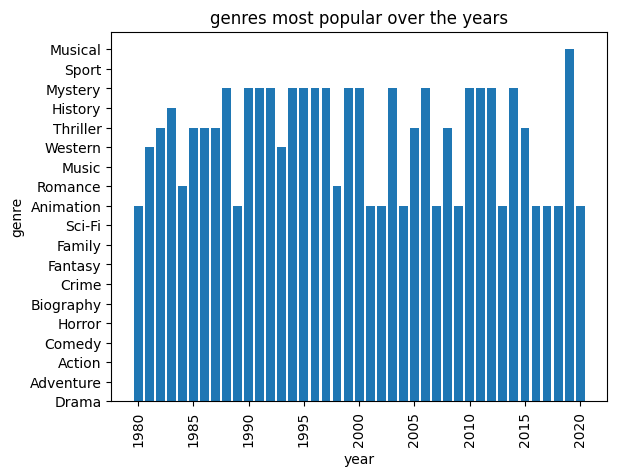

In [60]:

x = movies['year']
y = movies['genre']
plt.bar(x, y)
plt.title('genres most popular over the years')
plt.xlabel('year')
plt.ylabel('genre')
plt.xticks(rotation = 90)
plt.show()

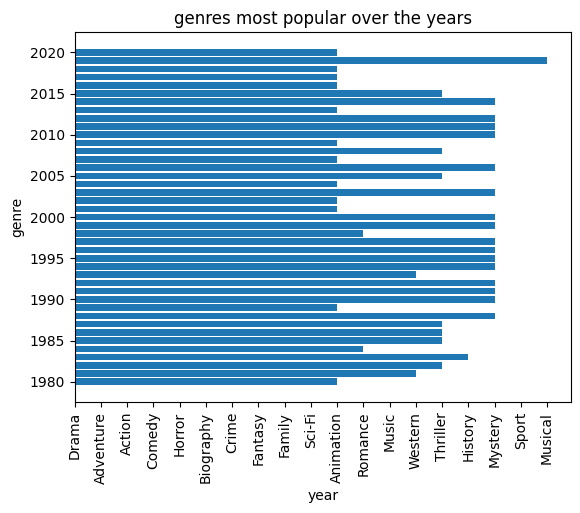

In [61]:
x = movies['year']
y = movies['genre']
plt.barh(x, y)
plt.title('genres most popular over the years')
plt.xlabel('year')
plt.ylabel('genre')
plt.xticks(rotation = 90)
plt.show()

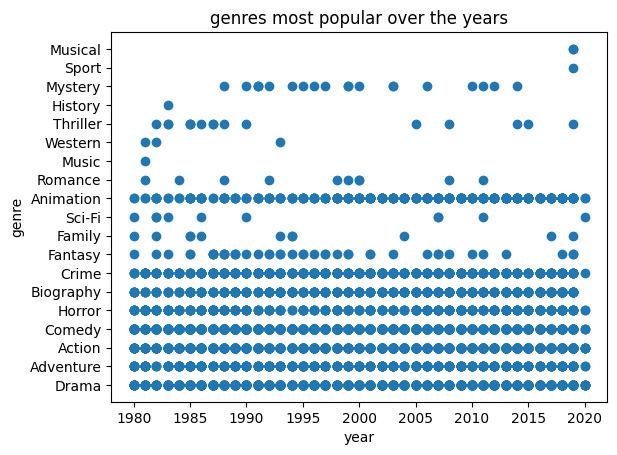

In [62]:
x = movies['year']
y = movies['genre']
plt.scatter(x, y)
plt.title('genres most popular over the years')
plt.xlabel('year')
plt.ylabel('genre')

plt.show()

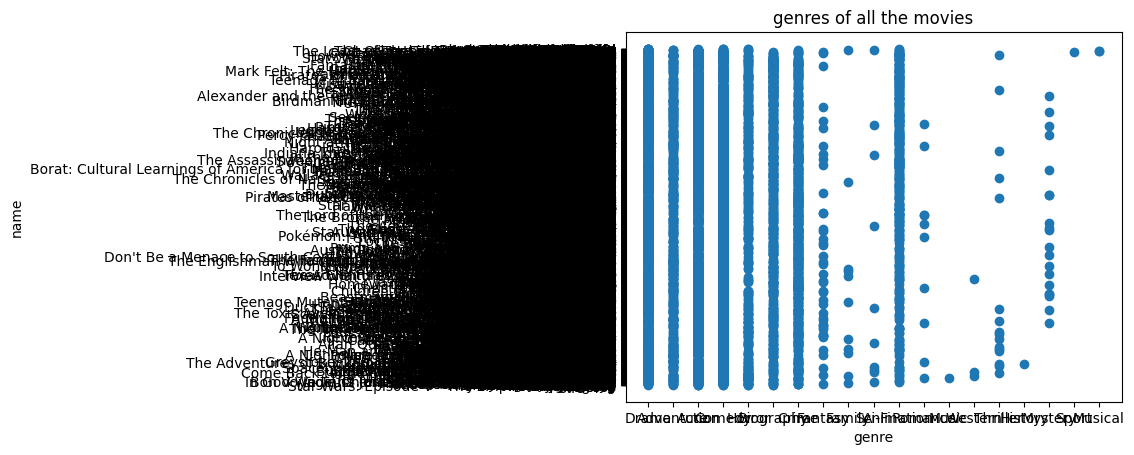

In [63]:
x = movies['genre']
y = movies['name']
plt.scatter(x, y)
plt.title('genres of all the movies')
plt.xlabel('genre')
plt.ylabel('name')

plt.show()
# I will fix this later
#I probably have to narrow down the information before doing a graph with the names

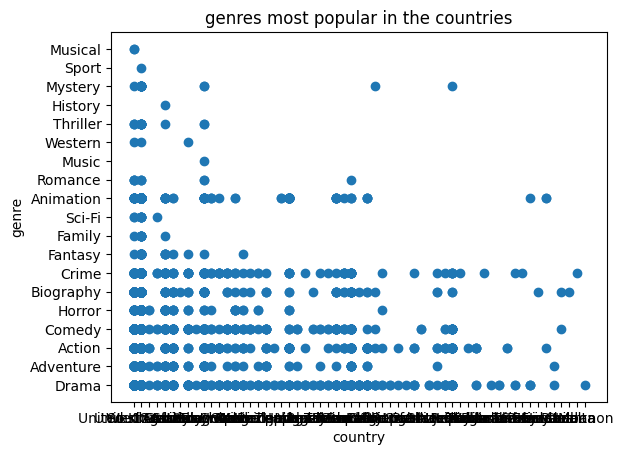

In [64]:
x = movies['country']
y = movies['genre']
plt.scatter(x, y)
plt.title('genres most popular in the countries')
plt.xlabel('country')
plt.ylabel('genre')

plt.show()
#I will fix the overlaping words in a bit

Drama seems the most popular throughout the countries

there is an about equal amount of popularity in the genres Action, Comedy, and Horror over the years, there is about the same popularity in Horror and Comedy in 1986 and 2020.

start cleanup

In [ ]:
'''
movies.iloc[1981:2020]
'''

'\nmovies.iloc[1981:2020]\n'

In [ ]:
# work on doing specific genres

In [65]:
movies['profit'] = movies['gross'] - movies['budget']
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   score     7665 non-null   float64
 5   votes     7665 non-null   float64
 6   director  7668 non-null   object 
 7   star      7667 non-null   object 
 8   country   7668 non-null   object 
 9   budget    5497 non-null   float64
 10  gross     7479 non-null   float64
 11  company   7651 non-null   object 
 12  runtime   7664 non-null   float64
 13  profit    5436 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 838.8+ KB


In [66]:
'''
movies = movies[['year'] == 1980] | movies[['year'] == 2020]
movies.info()
'''

"\nmovies = movies[['year'] == 1980] | movies[['year'] == 2020]\nmovies.info()\n"

In [ ]:
'''
movies = movies[['genre'] == 'Action'] | movies[['genre'] == 'Comedy']
movies.info()
'''

"\nmovies = movies[['genre'] == 'Action'] | movies[['genre'] == 'Comedy']\nmovies.info()\n"

In [ ]:
'''
movies = movies[['year'] == 1980] | movies[['year'] == 1990] | movies[['year'] == 2000] | movies[['year'] == 2010] | movies[['year'] == 2010]
movies.info()
'''

"\nmovies = movies[['year'] == 1980] | movies[['year'] == 1990] | movies[['year'] == 2000] | movies[['year'] == 2010] | movies[['year'] == 2010]\nmovies.info()\n"

In [67]:
#years to keep
years = [1980, 1990, 2000, 2010, 2020]

#filter the dataframe
filtered_movies = movies[(movies['genre'].isin(['Comedy','Action']))
& (movies['year'].isin(years))]

filtered_movies.head()

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime,profit
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,8.7,1200000.0,Irvin Kershner,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,520375067.0
3,Airplane!,PG,Comedy,1980,7.7,221000.0,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,79953539.0
4,Caddyshack,R,Comedy,1980,7.3,108000.0,Harold Ramis,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,33846344.0
6,The Blues Brothers,R,Action,1980,7.9,188000.0,John Landis,John Belushi,United States,27000000.0,115229890.0,Universal Pictures,133.0,88229890.0
8,Superman II,PG,Action,1980,6.8,101000.0,Richard Lester,Gene Hackman,United States,54000000.0,108185706.0,Dovemead Films,127.0,54185706.0


In [68]:
filtered_movies['year'].unique()

array([1980, 1990, 2000, 2010, 2020])

In [69]:
filtered_movies['genre'].unique()

array(['Action', 'Comedy'], dtype=object)

In [70]:
filtered_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379 entries, 2 to 7664
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      379 non-null    object 
 1   rating    375 non-null    object 
 2   genre     379 non-null    object 
 3   year      379 non-null    int64  
 4   score     378 non-null    float64
 5   votes     378 non-null    float64
 6   director  379 non-null    object 
 7   star      379 non-null    object 
 8   country   379 non-null    object 
 9   budget    271 non-null    float64
 10  gross     363 non-null    float64
 11  company   377 non-null    object 
 12  runtime   379 non-null    float64
 13  profit    266 non-null    float64
dtypes: float64(6), int64(1), object(7)
memory usage: 44.4+ KB


In [71]:
filtered_movies.isna().sum()

,0
name,0
rating,4
genre,0
year,0
score,1
votes,1
director,0
star,0
country,0
budget,108


In [72]:
filtered_movies[filtered_movies['gross'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime,profit
27,Raise the Titanic,PG,Action,1980,5.0,4100.0,Jerry Jameson,Jason Robards,United Kingdom,36000000.0,NaN,ITC Films,115.0,NaN
55,The Private Eyes,PG,Comedy,1980,6.7,2900.0,Lang Elliott,Tim Conway,United States,NaN,NaN,Tri Star Productions,91.0,NaN
62,It's My Turn,R,Comedy,1980,5.5,875.0,Claudia Weill,Jill Clayburgh,United States,NaN,NaN,Rastar Films,91.0,NaN
66,Moscow Does Not Believe in Tears,PG,Comedy,1980,8.1,12000.0,Vladimir Menshov,Vera Alentova,Soviet Union,900000.0,NaN,Mosfilm,150.0,NaN
91,Mantis Fist Fighter,NaN,Action,1980,6.7,230.0,Wing-Cho Yip,Ka-Yan Leung,Hong Kong,NaN,NaN,East Asia Film Company,89.0,NaN
1768,Side Out,PG-13,Comedy,1990,5.5,1900.0,Peter Israelson,C. Thomas Howell,United States,6000000.0,NaN,Aurora,100.0,NaN
1777,Madhouse,PG-13,Comedy,1990,5.5,3000.0,Tom Ropelewski,Richard Alexander,United States,NaN,NaN,Orion Pictures,90.0,NaN
1814,Boiling Point,Not Rated,Action,1990,6.8,6300.0,Takeshi Kitano,Takeshi Kitano,Japan,NaN,NaN,Bandai Visual Company,96.0,NaN
1822,The Shrimp on the Barbie,PG-13,Comedy,1990,5.7,1200.0,Director,Cheech Marin,Australia,NaN,NaN,Unity Pictures,90.0,NaN
1838,Heaven and Earth,PG-13,Action,1990,7.0,958.0,Haruki Kadokawa,Takaaki Enoki,Japan,42000000.0,NaN,Haruki Kadokawa Films,125.0,NaN


In [73]:
refiltered_movies = filtered_movies.dropna(subset=['gross'])
refiltered_movies['gross'].isna().sum()

np.int64(0)

In [74]:
refiltered_movies.isna().sum()

,0
name,0
rating,0
genre,0
year,0
score,0
votes,0
director,0
star,0
country,0
budget,97


In [75]:
refiltered_movies['budget'].describe()

,budget
count,2.660000e+02
mean,3.874005e+07
std,3.941070e+07
min,2.300000e+04
25%,1.100000e+07
50%,2.400000e+07
75%,5.500000e+07
max,2.050000e+08


In [76]:
refiltered_movies['budget'].mean()

np.float64(38740048.872180454)

In [77]:
mean = refiltered_movies['budget'].mean()

refiltered_movies['budget'] = refiltered_movies['budget'].fillna(value = mean)

refiltered_movies['budget'].isna().sum()

np.int64(0)

In [78]:
refiltered_movies.isna().sum()

,0
name,0
rating,0
genre,0
year,0
score,0
votes,0
director,0
star,0
country,0
budget,0


In [79]:
refiltered_movies[refiltered_movies['company'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime,profit
1806,Streets,R,Action,1990,5.7,712.0,Katt Shea,Christina Applegate,United States,3.874005e+07,1510053.0,NaN,85.0,NaN


In [80]:
refiltered_movies['company'].unique()

array(['Lucasfilm', 'Paramount Pictures', 'Orion Pictures',
       'Universal Pictures', 'Dovemead Films', 'The Malpaso Company',
       'IPC Films', 'Columbia Pictures', 'Bryna Productions',
       'Stephen Friedman/Kings Road Productions', 'Twentieth Century Fox',
       'Rastar Films', 'Warner Bros.', 'PolyGram Filmed Entertainment',
       'Camp Hill', 'Melvin Simon Productions',
       'Jack Rollins & Charles H. Joffe Productions',
       'Opera Film Produzione', 'International Cinema',
       'Mulberry Square Productions', 'American Cinema Productions',
       'Brooksfilms', 'Braun Entertainment Group',
       'Kings Road Entertainment', 'Alive Enterprises', 'Time Life Films',
       'Herb Jaffe', 'Da.Ma. Cinematografica', 'Chuck Barris Productions',
       'Broadway Productions', 'Metro-Goldwyn-Mayer (MGM)',
       'F.F. Associates', 'Carolco Pictures', 'Touchstone Pictures',
       'Hughes Entertainment', '888 Productions', 'Davis Entertainment',
       'Renaissance Pictures', 

In [81]:
refiltered_movies.loc[1806, 'company'] = 'Concorde Pictures'

In [82]:
refiltered_movies['profit'].mean()

np.float64(59292831.9887218)

In [83]:
profit_mean = refiltered_movies['profit'].mean()
refiltered_movies['profit'] = refiltered_movies['profit'].fillna(value = mean)

refiltered_movies['profit'].isna().sum()

np.int64(0)

In [110]:
refiltered_movies.isna().sum()

,0
name,0
rating,0
genre,0
year,0
score,0
votes,0
director,0
star,0
country,0
budget,0


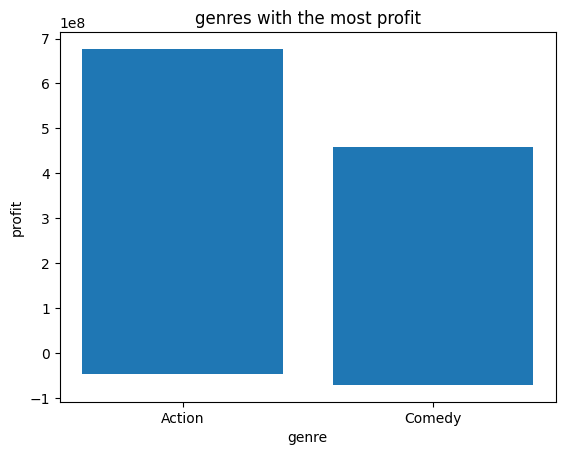

In [101]:
x = refiltered_movies['genre']
y = refiltered_movies['profit']
plt.bar(x, y)
plt.title('genres with the most profit')
plt.xlabel('genre')
plt.ylabel('profit')

plt.show()

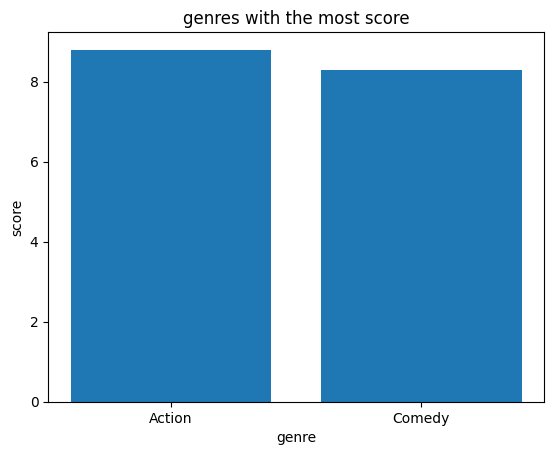

In [113]:
x = refiltered_movies['genre']
y = refiltered_movies['score']
plt.bar(x, y)
plt.title('genres with the most score')
plt.xlabel('genre')
plt.ylabel('score')

plt.show()

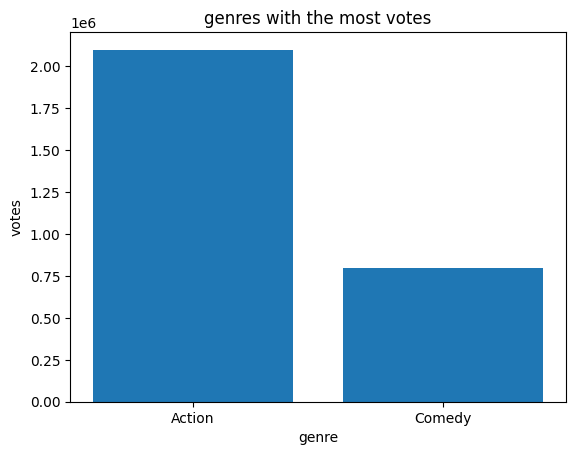

In [115]:
x = refiltered_movies['genre']
y = refiltered_movies['votes']
plt.bar(x, y)
plt.title('genres with the most votes')
plt.xlabel('genre')
plt.ylabel('votes')

plt.show()

In [107]:
refiltered_movies['star'].unique()

array(['Mark Hamill', 'Robert Hays', 'Chevy Chase', 'John Belushi',
       'Gene Hackman', 'Clint Eastwood', 'Jane Fonda', 'Gene Wilder',
       'Kirk Douglas', "Tatum O'Neal", 'Chris Makepeace', 'Burt Reynolds',
       'Goldie Hawn', 'Tony Danza', 'Rory Calhoun', "Peter O'Toole",
       'Cheech Marin', 'Michael Caine', 'Don Adams', 'Woody Allen',
       'Paul Le Mat', 'Marcello Mastroianni', 'Paul Newman',
       'Chuck Norris', 'Dom DeLuise', 'Peter Sellers', 'Martin Mull',
       'John Ritter', 'Dudley Moore', 'Marty Feldman', 'Meat Loaf',
       'Ali MacGraw', 'Walter Matthau', 'Michael Ontkean',
       'Shirley MacLaine', 'George Burns', 'Frank Langella',
       'Michel Serrault', 'Chuck Barris', 'Gilda Radner',
       'Treat Williams', 'Bob Newhart', 'Arnold Schwarzenegger',
       'Richard Gere', 'Macaulay Culkin', 'Kevin Bacon', 'Bruce Willis',
       'Tom Hanks', 'Judith Hoag', 'Sean Connery', 'Warren Beatty',
       'Nicolas Cage', 'Danny Glover', 'Peter Weller', 'Liam Neeson

In [108]:
refiltered_movies['director'].unique()

array(['Irvin Kershner', 'Jim Abrahams', 'Harold Ramis', 'John Landis',
       'Richard Lester', 'Buddy Van Horn', 'Colin Higgins',
       'Sidney Poitier', 'Don Taylor', 'Ron Maxwell', 'Tony Bill',
       'Hal Needham', 'Jay Sandrich', 'Howard Zieff', 'Floyd Mutrux',
       'Kevin Connor', 'Richard Rush', 'Tommy Chong', 'Michael Ritchie',
       'Clive Donner', 'Woody Allen', 'Jonathan Demme', 'Clint Eastwood',
       'Federico Fellini', 'James Goldstone', 'Joe Camp', 'Eric Karson',
       'Anne Bancroft', 'Piers Haggard', 'Bill Persky', 'Martin Davidson',
       'Gary Weis', 'Marty Feldman', 'Alan Rudolph', 'Sidney Lumet',
       'Walter Bernstein', 'Paul Mazursky', 'Jack Smight',
       'Gilbert Cates', 'Michael Pressman', 'Édouard Molinaro',
       'Chuck Barris', 'Mike Nichols', 'Larry Peerce', 'Buck Henry',
       'Paul Verhoeven', 'Garry Marshall', 'Chris Columbus',
       'Ron Underwood', 'Renny Harlin', 'Ivan Reitman', 'Brian De Palma',
       'Steve Barron', 'John McTiernan',

In [109]:
refiltered_movies['company'].unique()

array(['Lucasfilm', 'Paramount Pictures', 'Orion Pictures',
       'Universal Pictures', 'Dovemead Films', 'The Malpaso Company',
       'IPC Films', 'Columbia Pictures', 'Bryna Productions',
       'Stephen Friedman/Kings Road Productions', 'Twentieth Century Fox',
       'Rastar Films', 'Warner Bros.', 'PolyGram Filmed Entertainment',
       'Camp Hill', 'Melvin Simon Productions',
       'Jack Rollins & Charles H. Joffe Productions',
       'Opera Film Produzione', 'International Cinema',
       'Mulberry Square Productions', 'American Cinema Productions',
       'Brooksfilms', 'Braun Entertainment Group',
       'Kings Road Entertainment', 'Alive Enterprises', 'Time Life Films',
       'Herb Jaffe', 'Da.Ma. Cinematografica', 'Chuck Barris Productions',
       'Broadway Productions', 'Metro-Goldwyn-Mayer (MGM)',
       'F.F. Associates', 'Carolco Pictures', 'Touchstone Pictures',
       'Hughes Entertainment', '888 Productions', 'Davis Entertainment',
       'Renaissance Pictures', 

In [111]:
refiltered_movies['score'].unique()

array([8.7, 7.7, 7.3, 7.9, 6.8, 6.1, 6.9, 6.7, 6.5, 7.1, 5.3, 6.2, 6.3,
       6. , 5.1, 7. , 4.6, 5.4, 6.6, 4.7, 5.5, 5.2, 5.9, 5.8, 4.3, 7.5,
       7.6, 5.6, 7.2, 6.4, 5.7, 7.4, 4.8, 4.9, 4.4, 4. , 8.5, 8.3, 7.8,
       2.5, 3.7, 5. , 4.5, 8.8, 3.4, 3.8])

In [112]:
refiltered_movies['votes'].unique()

array([1.20e+06, 2.21e+05, 1.08e+05, 1.88e+05, 1.01e+05, 1.80e+04,
       2.90e+04, 2.60e+04, 2.20e+04, 5.10e+03, 8.90e+03, 1.50e+04,
       9.10e+03, 2.40e+04, 4.30e+03, 1.10e+04, 9.00e+03, 1.20e+04,
       3.90e+03, 3.10e+03, 4.50e+03, 6.70e+03, 2.60e+03, 2.40e+03,
       5.20e+03, 2.00e+03, 9.15e+02, 1.50e+03, 1.80e+03, 9.65e+02,
       1.10e+03, 5.85e+02, 1.40e+03, 4.15e+02, 3.51e+02, 2.10e+03,
       2.69e+02, 1.90e+03, 7.40e+02, 5.99e+02, 2.11e+02, 5.93e+02,
       3.10e+05, 2.99e+05, 5.01e+05, 1.26e+05, 3.44e+05, 1.40e+05,
       8.80e+04, 1.86e+05, 5.90e+04, 8.60e+04, 1.51e+05, 8.30e+04,
       6.00e+04, 5.70e+04, 6.50e+04, 8.10e+04, 9.50e+04, 3.20e+04,
       1.70e+04, 6.90e+04, 3.00e+04, 3.50e+04, 2.00e+04, 2.10e+04,
       3.40e+04, 2.30e+04, 1.90e+04, 1.40e+04, 4.00e+04, 1.60e+04,
       2.80e+04, 2.70e+04, 9.40e+03, 4.20e+04, 2.50e+03, 7.00e+03,
       1.30e+04, 5.00e+03, 4.50e+04, 1.00e+04, 4.20e+03, 7.60e+03,
       9.50e+03, 8.40e+03, 8.10e+03, 8.30e+03, 6.00e+03, 8.00e

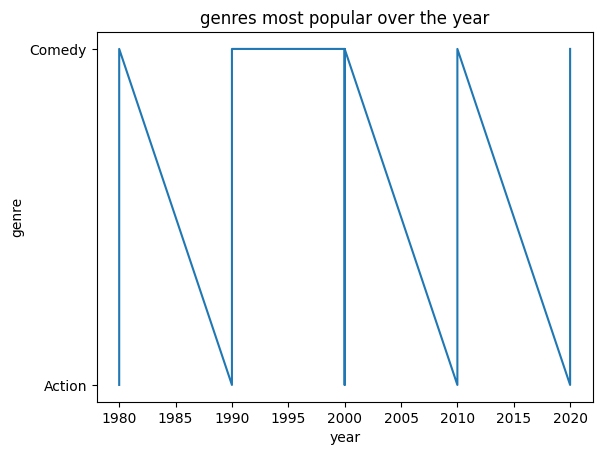

In [106]:
x = refiltered_movies['year']
y = refiltered_movies['genre']
plt.plot(x, y)
plt.title('genres most popular over the year')
plt.xlabel('year')
plt.ylabel('genre')

plt.show()

In [92]:
print(refiltered_movies['profit'].dtype)

float64


In [93]:
print(refiltered_movies.shape)




(363, 14)


In [94]:
print(refiltered_movies['profit'].isna().sum())



print(refiltered_movies['profit'].describe())

0
count    3.630000e+02
mean     5.380077e+07
std      9.459601e+07
min     -7.133109e+07
25%      9.755930e+05
50%      3.874005e+07
75%      5.027379e+07
max      6.768370e+08
Name: profit, dtype: float64


In [95]:
print(refiltered_movies['profit'].isna().sum())

0


In [96]:
print(refiltered_movies['genre'].dtype)



object


In [97]:
print(refiltered_movies['genre'].isna().sum())

0


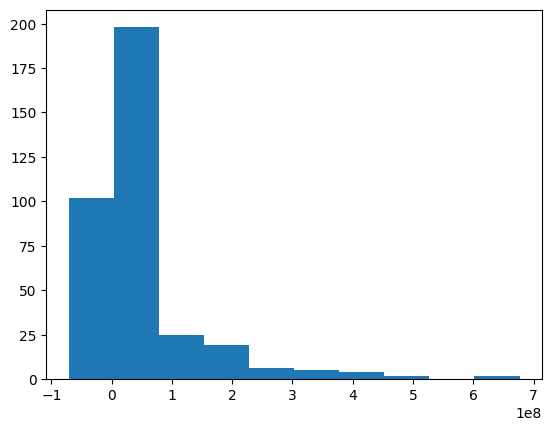

In [99]:
plt.hist(refiltered_movies['profit'])
plt.show()

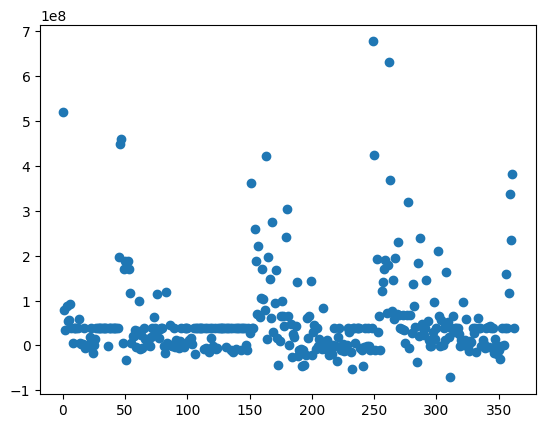

In [100]:
plt.scatter(range(len(refiltered_movies)), refiltered_movies['profit'])

plt.show()

In [ ]:
'''
filtered_movies.loc[7660, 'gross'] = 33562.0
'''

"\nfiltered_movies.loc[7660, 'gross'] = 33562.0\n"

In [ ]:
'''
filtered_movies[filtered_movies['gross'].isnull()]
'''

"\nfiltered_movies[filtered_movies['gross'].isnull()]\n"

In [ ]:
'''
filtered_movies.iloc[7660]
'''

'\nfiltered_movies.iloc[7660]\n'

In [ ]:
'''
movies_remove_na_gross = movies.dropna(subset=['gross'])
movies_remove_na_gross['gross'].isna().sum()
'''

"\nmovies_remove_na_gross = movies.dropna(subset=['gross'])\nmovies_remove_na_gross['gross'].isna().sum()\n"